In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

iris = pd.read_csv("iris (1).csv")
X = iris.drop("species", axis=1)
y = iris["species"]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {"n_neighbors": list(range(1,21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_k_iris = grid.best_params_["n_neighbors"]
model_iris = grid.best_estimator_

y_pred_iris = model_iris.predict(X_test)

print("IRIS DATASET RESULTS")
print("Chosen K value:", best_k_iris)
print("Accuracy:", accuracy_score(y_test, y_pred_iris))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_iris))
print("Classification Report:\n", classification_report(y_test, y_pred_iris))

IRIS DATASET RESULTS
Chosen K value: 6
Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
diabetes = pd.read_csv("diabetes.csv")
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

param_grid = {"n_neighbors": list(range(1,21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_k_diabetes = grid.best_params_["n_neighbors"]
model_diabetes = grid.best_estimator_

y_pred_diabetes = model_diabetes.predict(X_test)

print("\nDIABETES DATASET RESULTS")
print("Chosen K value:", best_k_diabetes)
print("Model Parameters:", model_diabetes.get_params())
print("Accuracy:", accuracy_score(y_test, y_pred_diabetes))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_diabetes))


DIABETES DATASET RESULTS
Chosen K value: 13
Model Parameters: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 13, 'p': 2, 'weights': 'uniform'}
Accuracy: 0.7597402597402597
Confusion Matrix:
 [[85 15]
 [22 32]]


Best K value: 12
Accuracy: 0.8688524590163934
Confusion Matrix:
 [[22  6]
 [ 2 31]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.79      0.85        28
           1       0.84      0.94      0.89        33

    accuracy                           0.87        61
   macro avg       0.88      0.86      0.87        61
weighted avg       0.87      0.87      0.87        61



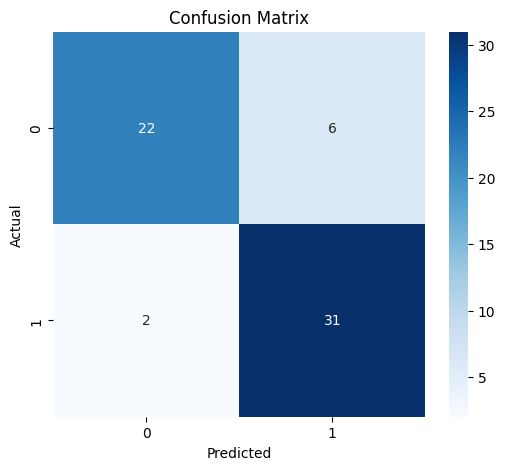

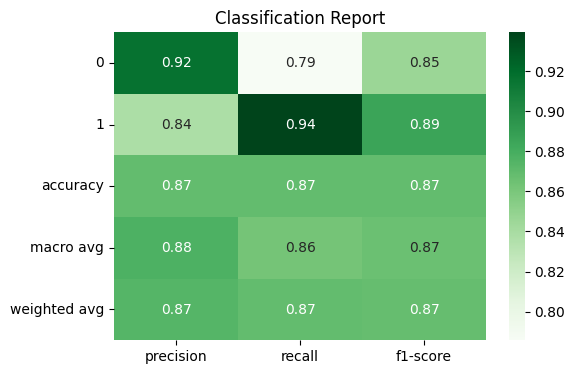

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("heart.csv")

X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

scores = {}
for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores[k] = accuracy_score(y_test, pred)

best_k = max(scores, key=scores.get)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)

print("Best K value:", best_k)
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap="Greens")
plt.title("Classification Report")
plt.show()